In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                           f1_score, precision_score, recall_score, 
                           accuracy_score, roc_auc_score, roc_curve)
from itertools import cycle
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef, balanced_accuracy_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import matplotlib.image as mpimg
from PIL import Image
import cairosvg
import io
import plotly.graph_objects as go
import base64
import plotly.io as pio
pio.renderers.default = 'vscode'
from scipy.stats import multivariate_normal


pd.options.display.float_format = '{:.2f}'.format
warnings.filterwarnings('ignore')

# Creating SA dataset

The data used below was scraped from Property24 website on 24 January 2026. It consists of listed houses, apartments/flats and townhouses.

Data:

- Gauteng listings: 93_560
    - Collected: 73_227
    - Clean: 30_471

- Eastern Cape: 8_975
    - Collected: 8_754
    - Clean: 5_949

- Free State: 7_613
    - Collected: 7_557
    - Clean: 4_608

- Kwazulu-natal: 31_102 
    - Collected: 25_726
    - Clean: 11_038

- Limpopo: 4_153
    - Collected: 4_355
    - Clean: 2817

- Mpumalanga: 7_918
    - Collected: 7_964
    - Clean: 5218

- North West: 10_937
    - Collected: 10_536
    - Clean: 5770

- Northern Cape: 2_291
    - Collected: 2_403
    - Clean: 1749

- Western Cape: 20_325
    - Collected: 18_ 486
    - Clean: 9888

In [3]:
ec = pd.read_csv('Eastern_Cape_property_data.csv')
fs = pd.read_csv('Free_State_property_data.csv')
g = pd.read_csv('Gauteng_property_data.csv')
lm = pd.read_csv('Limpopo_property_data.csv')
kzn = pd.read_csv('KZN_property_data.csv') 
mp = pd.read_csv('Mpumalanga_property_data.csv')
nw = pd.read_csv('North_West_property_data.csv')
nc = pd.read_csv('Northern_Cape_property_data.csv')
wc = pd.read_csv('Western_Cape_property_data.csv')

provinces = [ec, fs, g, lm, kzn, mp, nw, nc, wc]

#adding province column
for province in provinces:
    if province.equals(ec):
        province['Province'] = 'Eastern Cape'
    elif province.equals(fs):
        province['Province'] = 'Free State'
    elif province.equals(g):
        province['Province'] = 'Gauteng'
    elif province.equals(lm):
        province['Province'] = 'Limpopo'
    elif province.equals(kzn):
        province['Province'] = 'KZN'
    elif province.equals(mp):
        province['Province'] = 'Mpumalanga'
    elif province.equals(nw):
        province['Province'] = 'North West'
    elif province.equals(nc):
        province['Province'] = 'Northern Cape'
    elif province.equals(wc):
        province['Province'] = 'Western Cape'
    else:
        print("Province not found")

#combining all provinces into one dataframe
south_africa_property_data = pd.concat(provinces, ignore_index=True)
south_africa_property_data.to_csv('South_Africa_property_data.csv', index=False)

# Clean SA data

In [4]:
sa_data_map_centreal = pd.read_csv('South_Africa_property_data.csv')
sa_data_working = sa_data_map_centreal.copy()

# remove unnecessary columns
sa_data_working = sa_data_working.drop(["Details_URL", "Title", "Location"], axis=1)

# remove duplicates
print(f"Original data shape: {sa_data_working.shape}")
sa_data_working.drop_duplicates(inplace=True)
print(f"Data shape after removing duplicates: {sa_data_working.shape}")

# removing unrealistic property prices
sa_data_working = sa_data_working[sa_data_working['Price'] >= 500_000]
sa_data_working = sa_data_working[sa_data_working['Price'] < 100_000_000]
print(f"Data shape after removing unrealistic prices: {sa_data_working.shape}")

# modifying bed and bath figures(some figures include concatenated numbers, we want the first figure)
# If beds has three numbers (100 or more), remove the last digit
# sa_data_working.loc[sa_data_working['Beds'] >= 20, 'Beds'] //= 10

# If baths has three numbers, remove the last digit
# sa_data_working.loc[sa_data_working['Baths'] >= 20, 'Baths'] //= 10

# If garage is greater than 10, keep only the last digit
# sa_data_working.loc[sa_data_working['Garage'] == 100, 'Garage'] //= 10
# sa_data_working.loc[sa_data_working['Garage'] > 10, 'Garage'] %= 10

# addressing Nan values
sa_data_working['Beds'] = sa_data_working['Beds'].fillna(0)
sa_data_working['Baths'] = sa_data_working['Baths'].fillna(0)
sa_data_working['Garage'] = sa_data_working['Garage'].fillna(0)
sa_data_working['Price'] = sa_data_working['Price'].fillna(0)
sa_data_working = sa_data_working.dropna(how="all")
print(f"Data shape after dropping remaining NaN values: {sa_data_working.shape}")

# infer missing sqm using province average sqm
# calculation: sqm = price / avg price per sqm in the province
province_avg_price_per_sqm = sa_data_working.groupby('Province').apply(lambda x: (x['Price'] / x['Size_sqm']).mean())
def infer_sqm(row):
    if pd.isna(row['Size_sqm']) or row['Size_sqm'] == 0:
        avg_price_per_sqm = province_avg_price_per_sqm[row['Province']]
        inferred_sqm = row['Price'] / avg_price_per_sqm
        return inferred_sqm
    return row['Size_sqm']

sa_data_working['Size_sqm'] = sa_data_working.apply(infer_sqm, axis=1)

# remove price outliers
Q1 = sa_data_working['Price'].quantile(0.25)
Q3 = sa_data_working['Price'].quantile(0.75)
IQR = Q3 - Q1
sa_data_working = sa_data_working[(sa_data_working['Price'] >= Q1 - 1.5 * IQR) & (sa_data_working['Price'] <= Q3 + 1.5 * IQR)]

# remove size outliers
Q1_size = sa_data_working['Size_sqm'].quantile(0.25)
Q3_size = sa_data_working['Size_sqm'].quantile(0.75)
IQR_size = Q3_size - Q1_size
sa_data_working = sa_data_working[(sa_data_working['Size_sqm'] >= Q1_size - 1.5 * IQR_size) & (sa_data_working['Size_sqm'] <= Q3_size + 1.5 * IQR_size)]

# remove bed outliers
Q1_beds = sa_data_working['Beds'].quantile(0.25)
Q3_beds = sa_data_working['Beds'].quantile(0.75)
IQR_beds = Q3_beds - Q1_beds
sa_data_working = sa_data_working[(sa_data_working['Beds'] >= Q1_beds - 1.5 * IQR_beds) & (sa_data_working['Beds'] <= Q3_beds + 1.5 * IQR_beds)]

# remove bath outliers
Q1_baths = sa_data_working['Baths'].quantile(0.25)
Q3_baths = sa_data_working['Baths'].quantile(0.75)
IQR_baths = Q3_baths - Q1_baths
sa_data_working = sa_data_working[(sa_data_working['Baths'] >= Q1_baths - 1.5 * IQR_baths) & (sa_data_working['Baths'] <= Q3_baths + 1.5 * IQR_baths)]

# remove garage outliers
Q1_garage = sa_data_working['Garage'].quantile(0.25)
Q3_garage = sa_data_working['Garage'].quantile(0.75)
IQR_garage = Q3_garage - Q1_garage
sa_data_working = sa_data_working[(sa_data_working['Garage'] >= Q1_garage - 1.5 * IQR_garage) & (sa_data_working['Garage'] <= Q3_garage + 1.5 * IQR_garage)]

print(f"Final data shape outliers removed: {sa_data_working.shape}")

sa_data_working.to_csv('South_Africa_property_data_cleaned.csv', index=False)
sa_data_working.sort_values(by='Price', ascending=False)

Original data shape: (159008, 6)
Data shape after removing duplicates: (109097, 6)
Data shape after removing unrealistic prices: (102637, 6)
Data shape after dropping remaining NaN values: (102637, 6)
Final data shape outliers removed: (72685, 6)


,Price,Beds,Baths,Garage,Size_sqm,Province
33154,6250000.00,1.00,2.00,3.00,304.19,Gauteng
94048,6250000.00,3.00,3.00,4.00,781.41,KZN
145247,6250000.00,3.00,2.00,0.00,326.31,Western Cape
55950,6250000.00,4.00,3.00,3.00,959.00,Gauteng
154909,6250000.00,3.00,2.00,2.00,600.00,Western Cape
...,...,...,...,...,...,...
63730,500000.00,3.00,2.00,1.00,418.00,Gauteng
16067,500000.00,2.00,1.00,0.00,283.00,Free State
131845,500000.00,2.00,1.00,1.00,38.35,North West
6784,500000.00,3.00,2.00,2.00,326.00,Eastern Cape


# Descriptive Statistics

Provincial stats

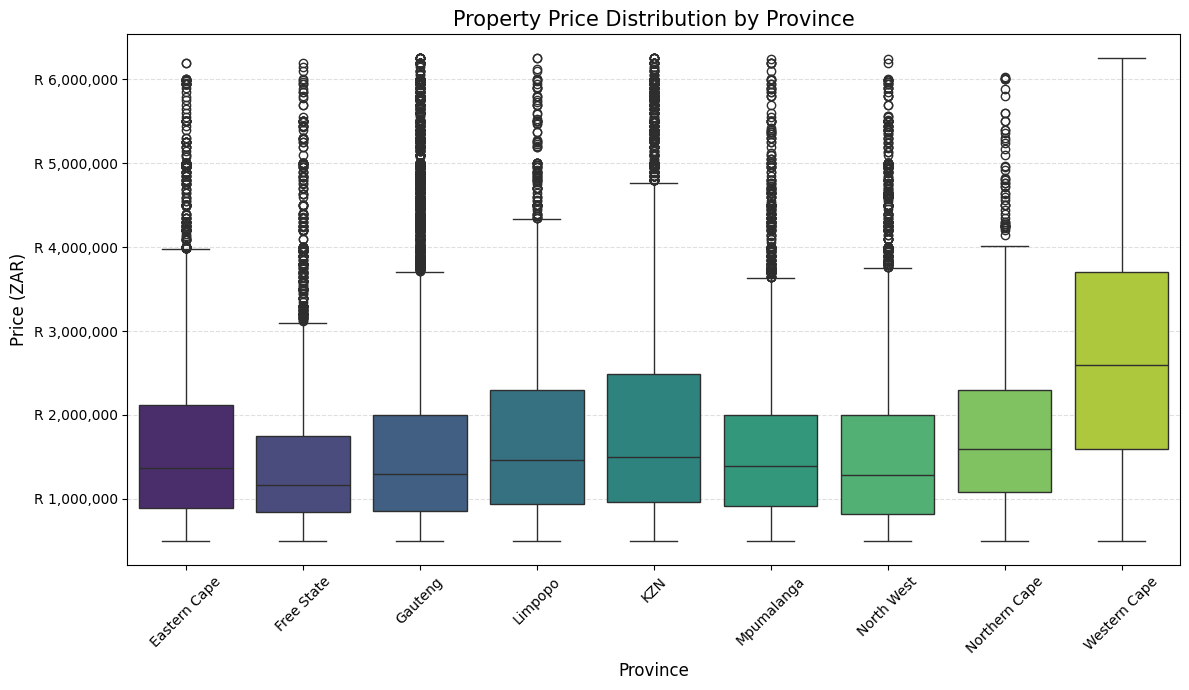

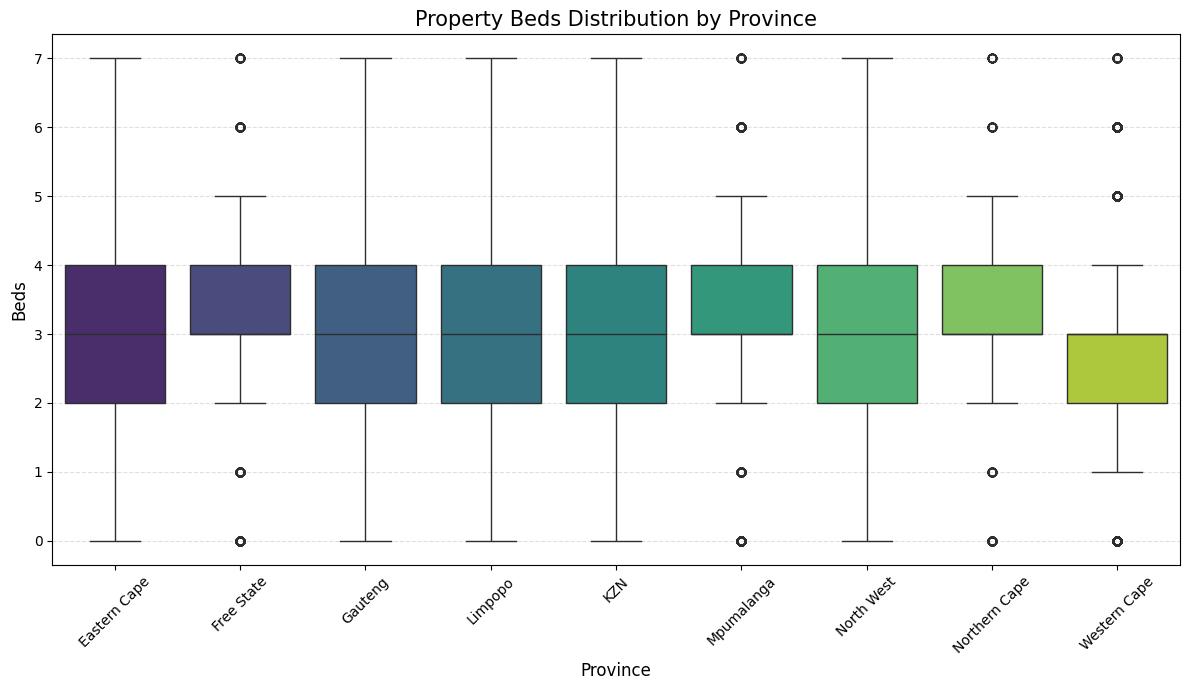

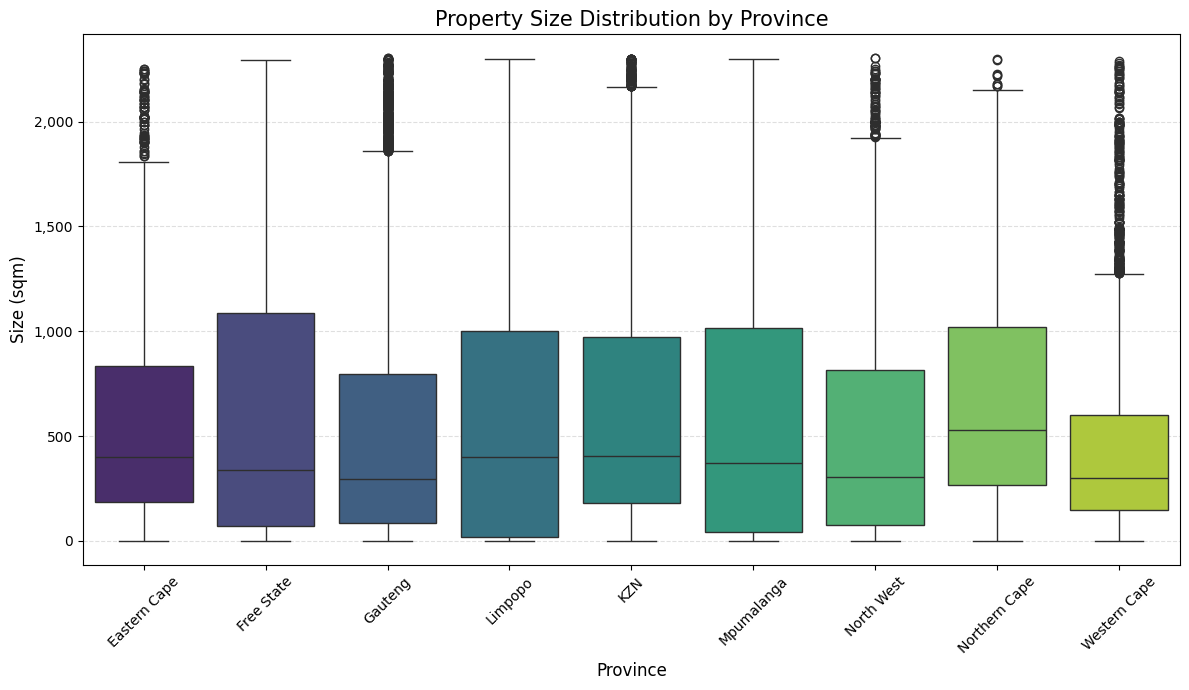

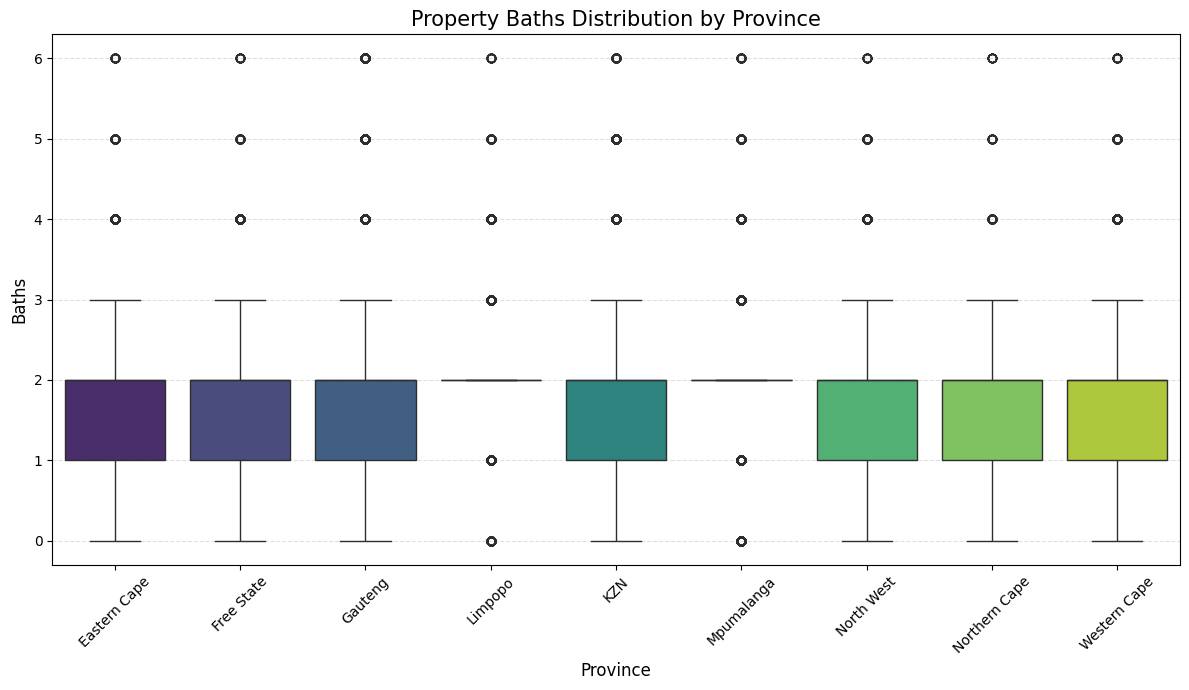

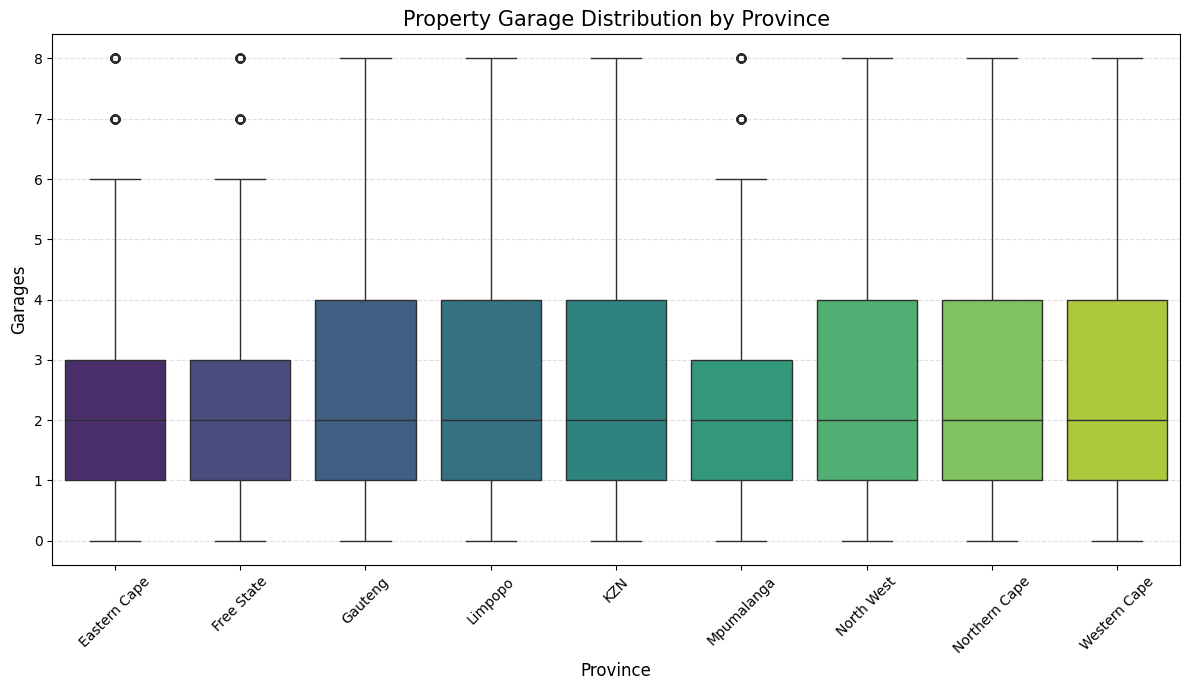

,Price,Beds,Baths,Garage,Size_sqm,Province,price_per_sqm
0,680000.00,2.00,1.00,1.00,237.00,Eastern Cape,2869.20
1,795000.00,2.00,1.00,2.00,321.00,Eastern Cape,2476.64
2,2995000.00,4.00,4.00,4.00,450.00,Eastern Cape,6655.56
3,750000.00,3.00,2.00,1.00,287.00,Eastern Cape,2613.24
4,585000.00,2.00,1.00,1.00,400.00,Eastern Cape,1462.50


In [5]:
clean_data = pd.read_csv('South_Africa_property_data_cleaned.csv')

# plot price distributions
# 1. Set the figure size
plt.figure(figsize=(12, 7))

# 2. Create the boxplot
# x is the category (Province), y is the numerical value (Price)
sns.boxplot(x='Province', y='Price', data=clean_data, palette='viridis')

# 3. Add Titles and Labels
plt.title('Property Price Distribution by Province', fontsize=15)
plt.xlabel('Province', fontsize=12)
plt.ylabel('Price (ZAR)', fontsize=12)

# 4. Rotate province names so they don't overlap
plt.xticks(rotation=45)

# 5. Format the y-axis to show Rand currency with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: 'R {:,.0f}'.format(x)))

# 6. Final layout adjustments
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# plot bed distributions
# 1. Set the figure size
plt.figure(figsize=(12, 7))

# 2. Create the boxplot
# x is the category (Province), y is the numerical value (Price)
sns.boxplot(x='Province', y='Beds', data=clean_data, palette='viridis')

# 3. Add Titles and Labels
plt.title('Property Beds Distribution by Province', fontsize=15)
plt.xlabel('Province', fontsize=12)
plt.ylabel('Beds', fontsize=12)

# 4. Rotate province names so they don't overlap
plt.xticks(rotation=45)

# 5. Format the y-axis to show Rand currency with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))

# 6. Final layout adjustments
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# plot size distribution
# 1. Set the figure size
plt.figure(figsize=(12, 7))

# 2. Create the boxplot
# x is the category (Province), y is the numerical value (Price)
sns.boxplot(x='Province', y='Size_sqm', data=clean_data, palette='viridis')

# 3. Add Titles and Labels
plt.title('Property Size Distribution by Province', fontsize=15)
plt.xlabel('Province', fontsize=12)
plt.ylabel('Size (sqm)', fontsize=12)

# 4. Rotate province names so they don't overlap
plt.xticks(rotation=45)

# 5. Format the y-axis to show Rand currency with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))

# 6. Final layout adjustments
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# plot bath distrinutions
# 1. Set the figure size
plt.figure(figsize=(12, 7))

# 2. Create the boxplot
# x is the category (Province), y is the numerical value (Price)
sns.boxplot(x='Province', y='Baths', data=clean_data, palette='viridis')

# 3. Add Titles and Labels
plt.title('Property Baths Distribution by Province', fontsize=15)
plt.xlabel('Province', fontsize=12)
plt.ylabel('Baths', fontsize=12)

# 4. Rotate province names so they don't overlap
plt.xticks(rotation=45)

# 5. Format the y-axis to show Rand currency with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))

# 6. Final layout adjustments
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# plot garage distributions
# 1. Set the figure size
plt.figure(figsize=(12, 7))

# 2. Create the boxplot
# x is the category (Province), y is the numerical value (Price)
sns.boxplot(x='Province', y='Garage', data=clean_data, palette='viridis')

# 3. Add Titles and Labels
plt.title('Property Garage Distribution by Province', fontsize=15)
plt.xlabel('Province', fontsize=12)
plt.ylabel('Garages', fontsize=12)

# 4. Rotate province names so they don't overlap
plt.xticks(rotation=45)

# 5. Format the y-axis to show Rand currency with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))

# 6. Final layout adjustments
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
listings_per_province = clean_data['Province'].value_counts()
average_price_per_province = clean_data.groupby('Province')['Price'].mean()
average_size_per_province = clean_data.groupby('Province')['Size_sqm'].mean()
average_price_per_sqm = clean_data.groupby('Province').apply(lambda x: (x['Price'] / x['Size_sqm']).mean())
average_bedrooms_per_province = clean_data.groupby('Province')['Beds'].mean()
average_bathrooms_per_province = clean_data.groupby('Province')['Baths'].mean()
average_garages_per_province = clean_data.groupby('Province')['Garage'].mean()

summary_df = pd.DataFrame({
    'Listings': listings_per_province,
    'Average Price': average_price_per_province,
    'Average Size (sqm)': average_size_per_province,
    'Average Price per sqm': average_price_per_sqm,
    'Average Bedrooms': average_bedrooms_per_province,
    'Average Bathrooms': average_bathrooms_per_province,
    'Average Garages': average_garages_per_province
})

clean_data['price_per_sqm'] = clean_data['Price'] / clean_data['Size_sqm']
# display(clean_data.head())
display(summary_df.head(9))
display(summary_df.describe())


# Data Analysis

In [19]:
# Convert SVG to PNG in memory
png_data = cairosvg.svg2png(url='Map_of_South_Africa_with_provincial_borders.svg')
img = Image.open(io.BytesIO(png_data))
img_array = np.array(img)

h, w = img_array.shape[:2]

# Encode image to base64 for plotly
buffered = io.BytesIO()
img.save(buffered, format="PNG")
img_b64 = base64.b64encode(buffered.getvalue()).decode()

# Create dense grid covering the entire image
x_grid = np.linspace(-w/2, w/2, w)
y_grid = np.linspace(-h/2, h/2, h)

fig = go.Figure()

# Heatmap with full grid coverage — all zeros so it's invisible
fig.add_trace(go.Heatmap(
    x=x_grid,
    y=y_grid,
    z=np.zeros((len(y_grid), len(x_grid))),  # invisible values
    showscale=False,
    opacity=0,                                 # fully transparent
    hovertemplate='x: %{x:.1f}<br>y: %{y:.1f}<extra></extra>'
))

fig.update_layout(
    images=[dict(
        source=f'data:image/png;base64,{img_b64}',
        xref='x', yref='y',
        x=-w/2, y=h/2,
        sizex=w, sizey=h,
        sizing='stretch',
        layer='below'
    )],
    xaxis=dict(range=[-w/2, w/2], showgrid=True, zeroline=True, zerolinecolor='white'),
    yaxis=dict(range=[-h/2, h/2], showgrid=True, zeroline=True, zerolinecolor='white',
               scaleanchor='x'),
    width=900,
    height=700,
    title='Interactive Map - Hover for Coordinates'
)

fig.write_html('map.html')
# fig.show()

In [51]:
png_data = cairosvg.svg2png(url='Map_of_South_Africa_with_provincial_borders.svg')
img = Image.open(io.BytesIO(png_data))
img_array = np.array(img)

h, w = img_array.shape[:2]

# Encode image to base64 for plotly
buffered = io.BytesIO()
img.save(buffered, format="PNG")
img_b64 = base64.b64encode(buffered.getvalue()).decode()

fig = go.Figure()

# --- Shear parameter ---
shear = 0.5   # adjust this to control how much the horizontal lines tilt

# Vertical lines — unchanged, straight up and down
for x in np.linspace(-w/2, w/2, 20):
    fig.add_trace(go.Scatter(
        x=[x, x],
        y=[-h/2, h/2],
        mode='lines',
        line=dict(color='rgba(255,255,255,0.3)', width=1),
        hoverinfo='skip',
        showlegend=False
    ))

# Horizontal lines — sheared, so they tilt diagonally
for y in np.linspace(-h/2, h/2, 20):
    x_start = -w/2
    x_end   =  w/2
    # shear shifts x position based on y value
    y_start = y + shear * x_start
    y_end   = y + shear * x_end
    fig.add_trace(go.Scatter(
        x=[x_start, x_end],
        y=[y_start, y_end],
        mode='lines',
        line=dict(color='rgba(255,255,255,0.3)', width=1),
        hoverinfo='skip',
        showlegend=False
    ))

# Invisible heatmap for hover coordinates
x_grid = np.linspace(-w/2, w/2, w)
y_grid = np.linspace(-h/2, h/2, h)

fig.add_trace(go.Heatmap(
    x=x_grid,
    y=y_grid,
    z=np.zeros((len(y_grid), len(x_grid))),
    showscale=False,
    opacity=0,
    hovertemplate='x: %{x:.1f}<br>y: %{y:.1f}<extra></extra>'
))

fig.update_layout(
    images=[dict(
        source=f'data:image/png;base64,{img_b64}',
        xref='x', yref='y',
        x=-w/2, y=h/2,
        sizex=w, sizey=h,
        sizing='stretch',
        layer='below'
    )],
    xaxis=dict(range=[-w/2, w/2], showgrid=True, zeroline=True, zerolinecolor='white'),
    yaxis=dict(range=[-h/2, h/2], showgrid=True, zeroline=True, zerolinecolor='white',
               scaleanchor='x'),
    width=900,
    height=700,
    title='Interactive Map - Hover for Coordinates'
)

fig.write_html('map2.html')

In [60]:
map_centre = np.array([0,0])

# province centre are offset from the map_centre
ec_mu = map_centre + np.array([74.1, -189.3])
fs_mu = map_centre + np.array([93.1,4])
gua_mu = map_centre + np.array([159.3,129.7])
kzn_mu = map_centre + np.array([275.3,-16])
lp_mu = map_centre + np.array([229.3,252.4])
mp_mu = map_centre + np.array([259.3,128.2])
nw_mu = map_centre + np.array([45.1,117.2])
nc_mu = map_centre + np.array([-147.2,-64.1])
wc_mu = map_centre + np.array([-193.2,-261.4])

ec_sig = np.array([[2000, 0],
                    [0,2000]])
fs_sig = np.array([[1500, 0],
                    [0,1500]])
gau_sig = np.array([[250, 0],
                    [0,250]])
kzn_sig = np.array([[1000, 0],
                    [0,1000]])
lp_sig = np.array([[1500, 0],
                    [0,1500]])
mp_sig = np.array([[1000, 0],
                    [0,1000]])
nw_sig = np.array([[1200, 0],
                    [0,1200]])
nc_sig = np.array([[4000, 0],
                    [0,4000]])
wc_sig = np.array([[1000, 0],
                    [0,1000]])
# Convert SVG to PNG in memory
png_data = cairosvg.svg2png(url='Map_of_South_Africa_with_provincial_borders.svg')
img = Image.open(io.BytesIO(png_data))
img_array = np.array(img)

h, w = img_array.shape[:2]

# Encode image to base64 for plotly
buffered = io.BytesIO()
img.save(buffered, format="PNG")
img_b64 = base64.b64encode(buffered.getvalue()).decode()

fig = go.Figure()

# Invisible heatmap for hover coordinates
x_grid = np.linspace(-w/2, w/2, w)
y_grid = np.linspace(-h/2, h/2, h)

fig.add_trace(go.Heatmap(
    x=x_grid,
    y=y_grid,
    z=np.zeros((len(y_grid), len(x_grid))),
    showscale=False,
    opacity=0,
    hovertemplate='x: %{x:.1f}<br>y: %{y:.1f}<extra></extra>'
))

# --- Plot Gaussians as contours ---
provinces = {
    'Eastern Cape':  (ec_mu,  ec_sig),
    'Free State':    (fs_mu,  fs_sig),
    'Gauteng':       (gua_mu, gau_sig),
    'KwaZulu-Natal': (kzn_mu, kzn_sig),
    'Limpopo':       (lp_mu,  lp_sig),
    'Mpumalanga':    (mp_mu,  mp_sig),
    'North West':    (nw_mu,  nw_sig),
    'Northern Cape': (nc_mu,  nc_sig),
    'Western Cape':  (wc_mu,  wc_sig),
}

colors = [
    '#e41a1c','#377eb8','#4daf4a','#984ea3',
    '#ff7f00','#a65628','#f781bf','#999999','#ffff33'
]

# Grid for evaluating Gaussian PDF
x_range = np.linspace(-w/2, w/2, 300)
y_range = np.linspace(-h/2, h/2, 300)
X, Y = np.meshgrid(x_range, y_range)
pos = np.stack([X, Y], axis=-1)

for (province, (mu, sig)), color in zip(provinces.items(), colors):
    dist = multivariate_normal(mean=mu, cov=sig)
    Z = dist.pdf(pos)

    # Contour lines
    fig.add_trace(go.Contour(
        x=x_range,
        y=y_range,
        z=Z,
        showscale=False,
        contours=dict(
            start=Z.max() * 0.1,
            end=Z.max() * 0.9,
            size=Z.max() * 0.2,
            coloring='none',        # no fill, just lines
        ),
        line=dict(color=color, width=2),
        name=province,
        hoverinfo='skip',
    ))

    # Dot at the mean
    fig.add_trace(go.Scatter(
        x=[mu[0]],
        y=[mu[1]],
        mode='markers+text',
        marker=dict(color=color, size=8),
        text=[province],
        textposition='top center',
        textfont=dict(color=color, size=10),
        name=province,
        showlegend=False,
        hovertemplate=f'{province}<br>x: {mu[0]:.1f}<br>y: {mu[1]:.1f}<extra></extra>'
    ))

fig.update_layout(
    images=[dict(
        source=f'data:image/png;base64,{img_b64}',
        xref='x', yref='y',
        x=-w/2, y=h/2,
        sizex=w, sizey=h,
        sizing='stretch',
        layer='below'
    )],
    xaxis=dict(range=[-w/2, w/2], showgrid=True, zeroline=True, zerolinecolor='white'),
    yaxis=dict(range=[-h/2, h/2], showgrid=True, zeroline=True, zerolinecolor='white',
               scaleanchor='x'),
    width=900,
    height=700,
    title='Province Gaussians on Map'
)

fig.write_html('map3.html')

In [61]:
# --- Shear transformation ---
shear = 0.5
T = np.array([[1,    0],
              [shear, 1]])

# Transform means
ec_mu  = T @ ec_mu
fs_mu  = T @ fs_mu
gua_mu = T @ gua_mu
kzn_mu = T @ kzn_mu
lp_mu  = T @ lp_mu
mp_mu  = T @ mp_mu
nw_mu  = T @ nw_mu
nc_mu  = T @ nc_mu
wc_mu  = T @ wc_mu

# Transform covariances — Σ' = T Σ Tᵀ
ec_sig  = T @ ec_sig  @ T.T
fs_sig  = T @ fs_sig  @ T.T
gau_sig = T @ gau_sig @ T.T
kzn_sig = T @ kzn_sig @ T.T
lp_sig  = T @ lp_sig  @ T.T
mp_sig  = T @ mp_sig  @ T.T
nw_sig  = T @ nw_sig  @ T.T
nc_sig  = T @ nc_sig  @ T.T
wc_sig  = T @ wc_sig  @ T.T

# Convert SVG to PNG in memory
png_data = cairosvg.svg2png(url='Map_of_South_Africa_with_provincial_borders.svg')
img = Image.open(io.BytesIO(png_data))
img_array = np.array(img)

h, w = img_array.shape[:2]

# Encode image to base64 for plotly
buffered = io.BytesIO()
img.save(buffered, format="PNG")
img_b64 = base64.b64encode(buffered.getvalue()).decode()

fig = go.Figure()

# Invisible heatmap for hover coordinates
x_grid = np.linspace(-w/2, w/2, w)
y_grid = np.linspace(-h/2, h/2, h)

fig.add_trace(go.Heatmap(
    x=x_grid,
    y=y_grid,
    z=np.zeros((len(y_grid), len(x_grid))),
    showscale=False,
    opacity=0,
    hovertemplate='x: %{x:.1f}<br>y: %{y:.1f}<extra></extra>'
))

# --- Plot Gaussians as contours ---
provinces = {
    'Eastern Cape':  (ec_mu,  ec_sig),
    'Free State':    (fs_mu,  fs_sig),
    'Gauteng':       (gua_mu, gau_sig),
    'KwaZulu-Natal': (kzn_mu, kzn_sig),
    'Limpopo':       (lp_mu,  lp_sig),
    'Mpumalanga':    (mp_mu,  mp_sig),
    'North West':    (nw_mu,  nw_sig),
    'Northern Cape': (nc_mu,  nc_sig),
    'Western Cape':  (wc_mu,  wc_sig),
}

colors = [
    '#e41a1c','#377eb8','#4daf4a','#984ea3',
    '#ff7f00','#a65628','#f781bf','#999999','#ffff33'
]

x_range = np.linspace(-w/2, w/2, 300)
y_range = np.linspace(-h/2, h/2, 300)
X, Y = np.meshgrid(x_range, y_range)
pos = np.stack([X, Y], axis=-1)

for (province, (mu, sig)), color in zip(provinces.items(), colors):
    dist = multivariate_normal(mean=mu, cov=sig)
    Z = dist.pdf(pos)

    fig.add_trace(go.Contour(
        x=x_range,
        y=y_range,
        z=Z,
        showscale=False,
        contours=dict(
            start=Z.max() * 0.1,
            end=Z.max() * 0.9,
            size=Z.max() * 0.2,
            coloring='none',
        ),
        line=dict(color=color, width=2),
        name=province,
        hoverinfo='skip',
    ))

    fig.add_trace(go.Scatter(
        x=[mu[0]],
        y=[mu[1]],
        mode='markers+text',
        marker=dict(color=color, size=8),
        text=[province],
        textposition='top center',
        textfont=dict(color=color, size=10),
        name=province,
        showlegend=False,
        hovertemplate=f'{province}<br>x: {mu[0]:.1f}<br>y: {mu[1]:.1f}<extra></extra>'
    ))

fig.update_layout(
    images=[dict(
        source=f'data:image/png;base64,{img_b64}',
        xref='x', yref='y',
        x=-w/2, y=h/2,
        sizex=w, sizey=h,
        sizing='stretch',
        layer='below'
    )],
    xaxis=dict(range=[-w/2, w/2], showgrid=True, zeroline=True, zerolinecolor='white'),
    yaxis=dict(range=[-h/2, h/2], showgrid=True, zeroline=True, zerolinecolor='white',
               scaleanchor='x'),
    width=900,
    height=700,
    title='Province Gaussians on Map (Sheared)'
)

fig.write_html('map4.html')

## - Positional Encoding

In [62]:
# euclidean space
map_centre = np.array([0,0])

# province centre are offset from the map_centre
ec_mu = map_centre + np.array([74.1, -189.3])
fs_mu = map_centre + np.array([93.1,4])
gua_mu = map_centre + np.array([159.3,129.7])
kzn_mu = map_centre + np.array([275.3,-16])
lp_mu = map_centre + np.array([229.3,252.4])
mp_mu = map_centre + np.array([259.3,128.2])
nw_mu = map_centre + np.array([45.1,117.2])
nc_mu = map_centre + np.array([-147.2,-64.1])
wc_mu = map_centre + np.array([-193.2,-261.4])

ec_sig = np.array([[2000, 0],
                    [0,2000]])
fs_sig = np.array([[1500, 0],
                    [0,1500]])
gau_sig = np.array([[250, 0],
                    [0,250]])
kzn_sig = np.array([[1000, 0],
                    [0,1000]])
lp_sig = np.array([[1500, 0],
                    [0,1500]])
mp_sig = np.array([[1000, 0],
                    [0,1000]])
nw_sig = np.array([[1200, 0],
                    [0,1200]])
nc_sig = np.array([[4000, 0],
                    [0,4000]])
wc_sig = np.array([[1000, 0],
                    [0,1000]])

# translation
translation = np.array([400, 350])

# transformation
transformation_matrix = np.array([[1,0],
                                 [0.5,1]])

# basis change
map_centre += translation
ec_mu += translation
fs_mu += translation
gua_mu += translation
kzn_mu += translation
lp_mu += translation
mp_mu += translation
nw_mu += translation
nc_mu += translation
wc_mu += translation
map_centre = transformation_matrix @ map_centre
ec_mu = transformation_matrix @ ec_mu
fs_mu = transformation_matrix @ fs_mu
gua_mu = transformation_matrix @ gua_mu
kzn_mu = transformation_matrix @ kzn_mu
lp_mu = transformation_matrix @ lp_mu
mp_mu = transformation_matrix @ mp_mu
nw_mu = transformation_matrix @ nw_mu
nc_mu = transformation_matrix @ nc_mu
# wc_mu = transformation_matrix @ wc_mu
# sigma = transformation_matrix @ sigma @ transformation_matrix.T

# 2d guassians
ec_pdf = multivariate_normal(mean=ec_mu, cov=ec_sig)
fs_pdf = multivariate_normal(mean=fs_mu, cov=fs_sig)
gua_pdf = multivariate_normal(mean=gua_mu, cov=gau_sig)
kzn_pdf = multivariate_normal(mean=kzn_mu, cov=kzn_sig)
lp_pdf = multivariate_normal(mean=lp_mu, cov=lp_sig)
mp_pdf = multivariate_normal(mean=mp_mu, cov=mp_sig)
nw_pdf = multivariate_normal(mean=nw_mu, cov=nw_sig)
nc_pdf = multivariate_normal(mean=nc_mu, cov=nc_sig)
wc_pdf = multivariate_normal(mean=wc_mu, cov=wc_sig)

# sampling location
pdf_map = {
    'Eastern Cape':  ec_pdf,
    'Free State':    fs_pdf,
    'Gauteng':       gua_pdf,
    'KZN':           kzn_pdf,
    'Limpopo':       lp_pdf,
    'Mpumalanga':    mp_pdf,
    'North West':    nw_pdf,
    'Northern Cape': nc_pdf,
    'Western Cape':  wc_pdf,
}

def sample_position(province):
    pdf = pdf_map[province]
    x, y = pdf.rvs()
    return pd.Series({'pos_x': x, 'pos_y': y})

clean_data[['pos_x', 'pos_y']] = clean_data['Province'].apply(sample_position)

display(clean_data.head(10))

,Price,Beds,Baths,Garage,Size_sqm,Province,price_per_sqm,pos_x,pos_y
0,680000.00,2.00,1.00,1.00,237.00,Eastern Cape,2869.20,413.36,355.97
1,795000.00,2.00,1.00,2.00,321.00,Eastern Cape,2476.64,454.60,367.13
2,2995000.00,4.00,4.00,4.00,450.00,Eastern Cape,6655.56,482.49,332.25
3,750000.00,3.00,2.00,1.00,287.00,Eastern Cape,2613.24,454.06,428.16
4,585000.00,2.00,1.00,1.00,400.00,Eastern Cape,1462.50,482.48,444.83
5,1195000.00,2.00,2.00,2.00,130.53,Eastern Cape,9155.20,479.28,371.07
6,900000.00,2.00,1.00,1.00,98.30,Eastern Cape,9155.20,447.81,402.00
7,795000.00,1.00,1.00,1.00,86.84,Eastern Cape,9155.20,408.06,375.26
8,2495000.00,4.00,3.00,6.00,1098.00,Eastern Cape,2272.31,480.90,351.51
9,3950000.00,4.00,3.00,6.00,694.00,Eastern Cape,5691.64,412.65,305.07


# - linear algebra stuff

In [63]:
drop_province = clean_data.drop(['Province'], axis=1)
np_data =  drop_province.to_numpy()
mu = np.mean(np_data, axis=0)
sigma = np.std(np_data, axis=0)
normalized_data = (np_data - mu) / sigma

rank = np.linalg.matrix_rank(normalized_data) 

# feature importance 
cov_matrix = np.cov(normalized_data, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

feature_importance = eigenvalues / np.sum(eigenvalues)
for i, importance in enumerate(feature_importance):
    print(f"Principal Component {i+1}: {importance:.4f}")

# change of basis(aligning data along eigenspace)
# decouples the correlated features
pc_data = np.dot(normalized_data, eigenvectors)


Principal Component 1: 0.3205
Principal Component 2: 0.2431
Principal Component 3: 0.0187
Principal Component 4: 0.0351
Principal Component 5: 0.1313
Principal Component 6: 0.0746
Principal Component 7: 0.0839
Principal Component 8: 0.0927


# - Neural Network

DATA PREPROCESSING
Encoding province labels...
Number of unique provinces: 9
Training samples: 58148
Testing samples: 14537
Input dimension: 8
Output dimension (number of classes): 9

TRAINING WITH CROSSENTROPY LOSS
Epoch 1/20
  Train Loss: 0.6025, Train Acc: 81.84%
  Val Loss: 0.2535, Val Acc: 91.02%
  Val F1: 0.8869, Val Precision: 0.8700, Val Recall: 0.9102
Epoch 2/20
  Train Loss: 0.2696, Train Acc: 90.74%
  Val Loss: 0.2142, Val Acc: 91.71%
  Val F1: 0.8954, Val Precision: 0.8820, Val Recall: 0.9171
Epoch 3/20
  Train Loss: 0.2557, Train Acc: 90.89%
  Val Loss: 0.2091, Val Acc: 91.86%
  Val F1: 0.8958, Val Precision: 0.8804, Val Recall: 0.9186
Epoch 4/20
  Train Loss: 0.2505, Train Acc: 91.05%
  Val Loss: 0.2069, Val Acc: 91.98%
  Val F1: 0.8976, Val Precision: 0.8837, Val Recall: 0.9198
Epoch 5/20
  Train Loss: 0.2489, Train Acc: 91.08%
  Val Loss: 0.2127, Val Acc: 91.81%
  Val F1: 0.8952, Val Precision: 0.8797, Val Recall: 0.9181
Epoch 6/20
  Train Loss: 0.2476, Train Acc: 91.07

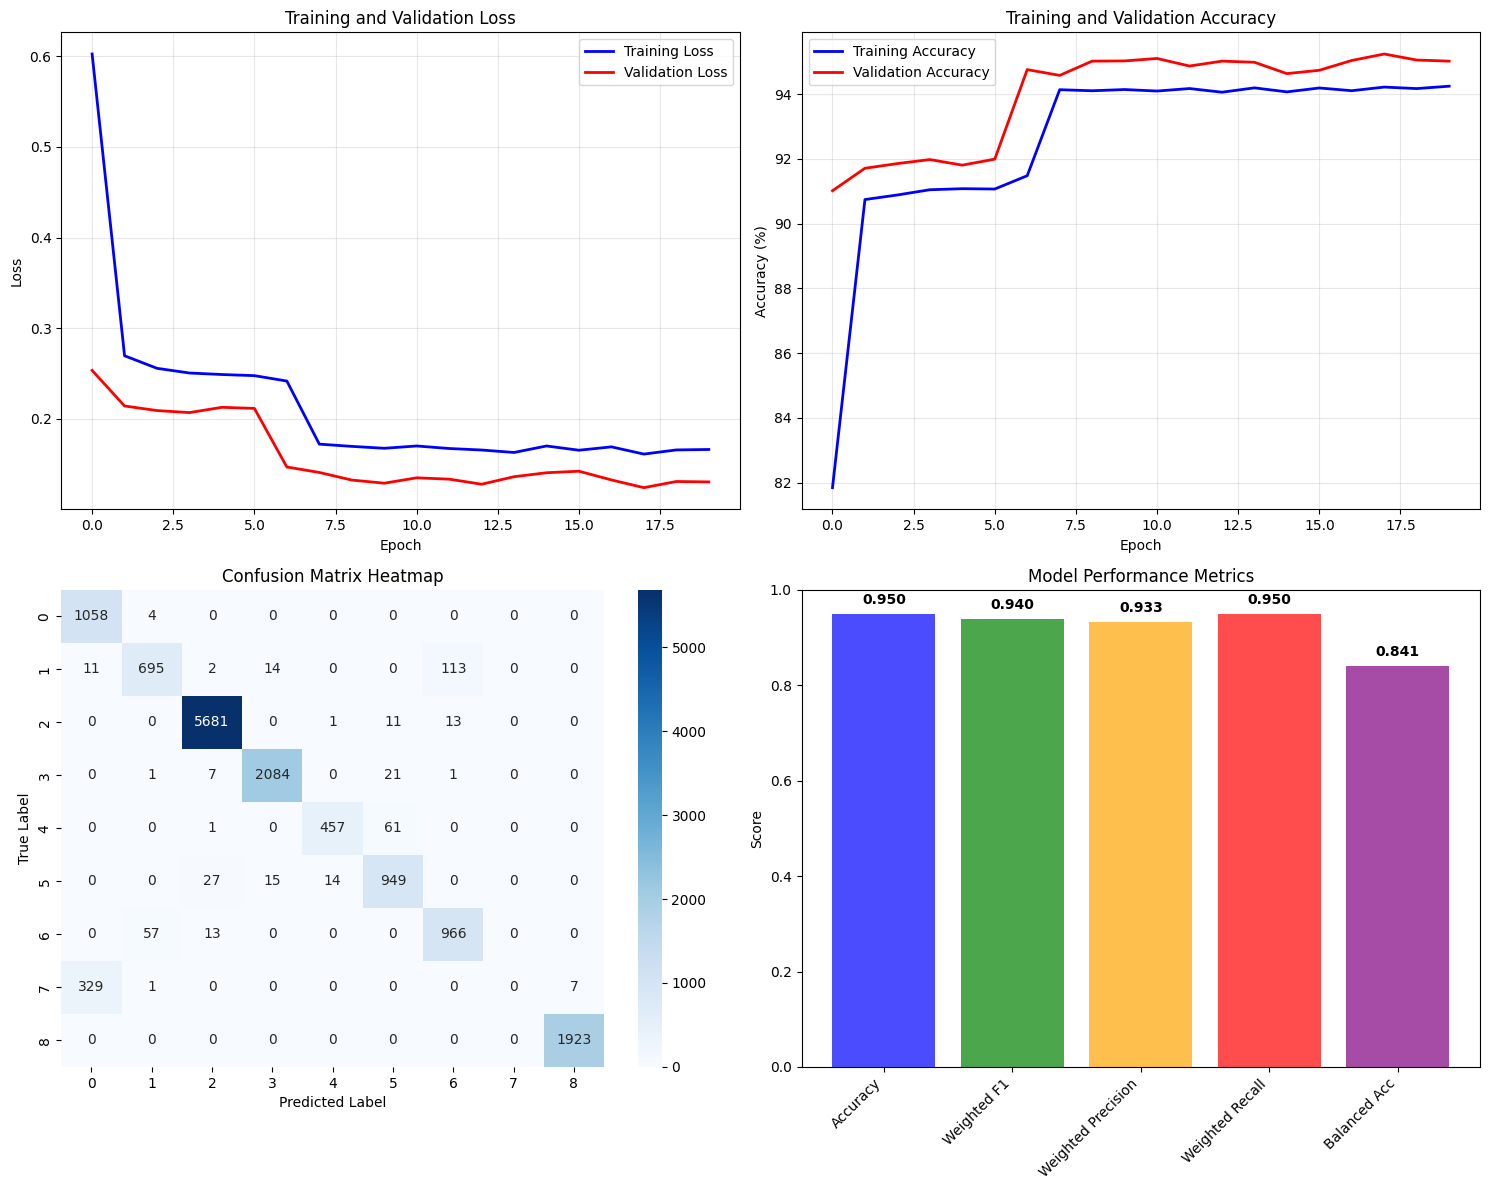


Visualization saved as 'model_evaluation_metrics.png'

MODEL PERFORMANCE SUMMARY
Best Validation Accuracy: 95.24%
Best Validation F1-Score: 0.9400
Final Model Performance on Test Set:
  - Accuracy: 0.9502
  - Weighted F1-Score: 0.9400
  - Cohen's Kappa: 0.9366
  - MCC: 0.9372


In [64]:
provinces = clean_data['Province'].values
onehot_encoder = OneHotEncoder(sparse_output=False)
provinces_onehot = onehot_encoder.fit_transform(provinces.reshape(-1, 1))

# 1. Preprocessing and Data Preparation
print("=" * 50)
print("DATA PREPROCESSING")
print("=" * 50)

# Check and encode provinces if needed
if isinstance(provinces[0], str) or isinstance(provinces[0], object):
    print("Encoding province labels...")
    le = LabelEncoder()
    provinces_encoded = le.fit_transform(provinces)
    num_classes = len(np.unique(provinces_encoded))
    print(f"Number of unique provinces: {num_classes}")
    
    # Save class names for reporting
    class_names = le.classes_
    
    # One-hot encode for MSE loss (or for probability outputs)
    onehot_encoder = OneHotEncoder(sparse_output=False)
    provinces_onehot = onehot_encoder.fit_transform(provinces_encoded.reshape(-1, 1))
    
    # For CrossEntropy loss, we'll use the encoded labels (not one-hot)
    y_for_ce = torch.tensor(provinces_encoded, dtype=torch.long)
    y_for_mse = torch.tensor(provinces_onehot, dtype=torch.float32)
    
else:
    # If already numerical
    num_classes = len(np.unique(provinces))
    print(f"Number of unique provinces: {num_classes}")
    
    if len(provinces.shape) == 2 and provinces.shape[1] > 1:
        # Already one-hot encoded
        provinces_onehot = provinces
        # Convert to class indices for CrossEntropy
        provinces_encoded = np.argmax(provinces, axis=1)
    else:
        # Label encoded
        provinces_encoded = provinces
        onehot_encoder = OneHotEncoder(sparse_output=False)
        provinces_onehot = onehot_encoder.fit_transform(provinces.reshape(-1, 1))
    
    class_names = [f"Class_{i}" for i in range(num_classes)]
    y_for_ce = torch.tensor(provinces_encoded, dtype=torch.long)
    y_for_mse = torch.tensor(provinces_onehot, dtype=torch.float32)

# Convert features to tensor
X_tensor = torch.tensor(normalized_data, dtype=torch.float32)

# Split indices to maintain alignment
indices = list(range(len(normalized_data)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=provinces_encoded)

# Split the data
X_train, X_test = X_tensor[train_idx], X_tensor[test_idx]
y_train_ce, y_test_ce = y_for_ce[train_idx], y_for_ce[test_idx]

# Create datasets
train_dataset_ce = TensorDataset(X_train, y_train_ce)
test_dataset_ce = TensorDataset(X_test, y_test_ce)

# Create DataLoaders
batch = 512
train_loader_ce = DataLoader(train_dataset_ce, batch_size=batch, shuffle=True)
test_loader_ce = DataLoader(test_dataset_ce, batch_size=batch, shuffle=False)

print(f"Training samples: {len(train_idx)}")
print(f"Testing samples: {len(test_idx)}")
print(f"Input dimension: {pc_data.shape[1]}")
print(f"Output dimension (number of classes): {num_classes}")

# 2. Model Definition
class RealEstateModel(nn.Module):
    def __init__(self, input_dim, output_dim, dropout_rate=0.2):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn2 = nn.BatchNorm1d(128)       
        self.fc2 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(64)       
        self.fc3 = nn.Linear(128, 64)
        self.bn4 = nn.BatchNorm1d(32)       
        self.fc4 = nn.Linear(64, 32)       
        self.fc5 = nn.Linear(32, output_dim)
        
    def forward(self, x):
        x = self.dropout(torch.relu(self.bn1(self.fc1(x))))
        x = self.dropout(torch.relu(self.bn2(self.fc2(x))))
        x = self.dropout(torch.relu(self.bn3(self.fc3(x))))
        x = self.dropout(torch.relu(self.bn4(self.fc4(x))))
        x = torch.relu(self.fc5(x))
        return x

print("\n" + "=" * 50)
print("TRAINING WITH CROSSENTROPY LOSS")
print("=" * 50)

model_ce = RealEstateModel(input_dim=pc_data.shape[1], output_dim=num_classes)
optimizer_ce = torch.optim.Adam(model_ce.parameters(), lr=0.01, weight_decay=1e-4)
loss_fn_ce = nn.CrossEntropyLoss()

epochs = 20
train_losses_ce = []
val_losses_ce = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    # Training phase
    model_ce.train()
    epoch_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader_ce:
        optimizer_ce.zero_grad()
        outputs = model_ce(inputs)
        loss = loss_fn_ce(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ce.parameters(), max_norm=1.0)
        optimizer_ce.step()
        
        epoch_train_loss += loss.item()
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    
    avg_train_loss = epoch_train_loss / len(train_loader_ce)
    train_accuracy = 100 * correct_train / total_train
    train_losses_ce.append(avg_train_loss)
    train_accuracies.append(train_accuracy)
    
    # Validation phase
    model_ce.eval()
    epoch_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader_ce:
            outputs = model_ce(inputs)
            loss = loss_fn_ce(outputs, labels)
            epoch_val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_val_loss = epoch_val_loss / len(test_loader_ce)
    val_accuracy = 100 * correct_val / total_val
    val_losses_ce.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    
    # Calculate F1 score for validation
    val_f1 = f1_score(all_labels, all_preds, average='weighted')
    val_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    val_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%")
    print(f"  Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")
    print(f"  Val F1: {val_f1:.4f}, Val Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f}")

# 4. Comprehensive Model Evaluation
print("\n" + "=" * 50)
print("COMPREHENSIVE MODEL EVALUATION")
print("=" * 50)

model_ce.eval()
all_predictions = []
all_true_labels = []
all_probabilities = []

with torch.no_grad():
    for inputs, labels in test_loader_ce:
        outputs = model_ce(inputs)
        probabilities = torch.softmax(outputs, dim=1)
        
        _, predicted = torch.max(outputs, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

# Convert to numpy arrays
all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)
all_probabilities = np.array(all_probabilities)

# 4.1 Classification Report
print("\n1. CLASSIFICATION REPORT:")
print("-" * 50)
report = classification_report(all_true_labels, all_predictions, 
                              target_names=class_names if hasattr(class_names, '__len__') else None,
                              digits=4)
print(report)

# 4.2 Confusion Matrix
print("\n2. CONFUSION MATRIX:")
print("-" * 50)
cm = confusion_matrix(all_true_labels, all_predictions)
cm_df = pd.DataFrame(cm, 
                     index=class_names if hasattr(class_names, '__len__') else [f'Class {i}' for i in range(num_classes)],
                     columns=class_names if hasattr(class_names, '__len__') else [f'Class {i}' for i in range(num_classes)])

print("Confusion Matrix:")
print(cm_df)

# 4.3 Detailed Metrics by Class
print("\n3. DETAILED METRICS BY CLASS:")
print("-" * 50)
metrics_by_class = []
for i in range(num_classes):
    class_name = class_names[i] if hasattr(class_names, '__len__') else f'Class {i}'
    
    # Precision, Recall, F1 for this class
    precision = precision_score(all_true_labels == i, all_predictions == i, zero_division=0)
    recall = recall_score(all_true_labels == i, all_predictions == i, zero_division=0)
    f1 = f1_score(all_true_labels == i, all_predictions == i, zero_division=0)
    
    # Support (number of samples)
    support = np.sum(all_true_labels == i)
    
    metrics_by_class.append({
        'Class': class_name,
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}",
        'Support': support
    })

metrics_df = pd.DataFrame(metrics_by_class)
print(metrics_df.to_string(index=False))

# 4.4 Overall Metrics
print("\n4. OVERALL METRICS:")
print("-" * 50)
accuracy = accuracy_score(all_true_labels, all_predictions)
macro_f1 = f1_score(all_true_labels, all_predictions, average='macro')
weighted_f1 = f1_score(all_true_labels, all_predictions, average='weighted')
macro_precision = precision_score(all_true_labels, all_predictions, average='macro', zero_division=0)
weighted_precision = precision_score(all_true_labels, all_predictions, average='weighted', zero_division=0)
macro_recall = recall_score(all_true_labels, all_predictions, average='macro', zero_division=0)
weighted_recall = recall_score(all_true_labels, all_predictions, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Weighted Recall: {weighted_recall:.4f}")

# 4.5 ROC-AUC for multi-class (if 2 classes, use binary; if more, use one-vs-rest)
if num_classes == 2:
    # Binary classification
    roc_auc = roc_auc_score(all_true_labels, all_probabilities[:, 1])
    print(f"\nROC-AUC Score (Binary): {roc_auc:.4f}")
else:
    # Multi-class classification
    try:
        # One-vs-rest ROC AUC
        roc_auc_ovr = roc_auc_score(all_true_labels, all_probabilities, multi_class='ovr', average='weighted')
        print(f"\nROC-AUC Score (One-vs-Rest, weighted): {roc_auc_ovr:.4f}")
        
        # One-vs-one ROC AUC
        roc_auc_ovo = roc_auc_score(all_true_labels, all_probabilities, multi_class='ovo', average='weighted')
        print(f"ROC-AUC Score (One-vs-One, weighted): {roc_auc_ovo:.4f}")
    except:
        print("\nNote: ROC-AUC calculation requires probability estimates for all classes")

# 4.6 Additional Metrics
print("\n5. ADDITIONAL METRICS:")
print("-" * 50)
# Calculate Cohen's Kappa
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(all_true_labels, all_predictions)
print(f"Cohen's Kappa: {kappa:.4f}")

# Calculate Matthews Correlation Coefficient (good for imbalanced data)
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(all_true_labels, all_predictions)
print(f"Matthews Correlation Coefficient: {mcc:.4f}")

# Calculate Balanced Accuracy
from sklearn.metrics import balanced_accuracy_score
bal_acc = balanced_accuracy_score(all_true_labels, all_predictions)
print(f"Balanced Accuracy: {bal_acc:.4f}")

# 6. Visualization
print("\n" + "=" * 50)
print("VISUALIZATION")
print("=" * 50)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 6.1 Training History
ax1 = axes[0, 0]
ax1.plot(train_losses_ce, label='Training Loss', color='blue', linewidth=2)
ax1.plot(val_losses_ce, label='Validation Loss', color='red', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.plot(train_accuracies, label='Training Accuracy', color='blue', linewidth=2)
ax2.plot(val_accuracies, label='Validation Accuracy', color='red', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 6.2 Confusion Matrix Heatmap
ax3 = axes[1, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(num_classes), 
            yticklabels=range(num_classes),
            ax=ax3)
ax3.set_xlabel('Predicted Label')
ax3.set_ylabel('True Label')
ax3.set_title('Confusion Matrix Heatmap')

# 6.3 Metrics Bar Chart
ax4 = axes[1, 1]
metrics_summary = {
    'Accuracy': accuracy,
    'Weighted F1': weighted_f1,
    'Weighted Precision': weighted_precision,
    'Weighted Recall': weighted_recall,
    'Balanced Acc': bal_acc
}
colors = ['blue', 'green', 'orange', 'red', 'purple']
ax4.bar(range(len(metrics_summary)), list(metrics_summary.values()), 
        color=colors, alpha=0.7)
ax4.set_xticks(range(len(metrics_summary)))
ax4.set_xticklabels(list(metrics_summary.keys()), rotation=45, ha='right')
ax4.set_ylabel('Score')
ax4.set_title('Model Performance Metrics')
ax4.set_ylim([0, 1])
for i, v in enumerate(metrics_summary.values()):
    ax4.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'model_evaluation_metrics.png'")

# 7. Summary Report
print("\n" + "=" * 50)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 50)
print(f"Best Validation Accuracy: {max(val_accuracies):.2f}%")
print(f"Best Validation F1-Score: {weighted_f1:.4f}")
print(f"Final Model Performance on Test Set:")
print(f"  - Accuracy: {accuracy:.4f}")
print(f"  - Weighted F1-Score: {weighted_f1:.4f}")
print(f"  - Cohen's Kappa: {kappa:.4f}")
print(f"  - MCC: {mcc:.4f}")

# Random Forest

Accuracy: 0.983008873907959

Classification Report:
                precision    recall  f1-score   support

 Eastern Cape       0.99      0.99      0.99      1062
   Free State       0.94      0.93      0.93       835
      Gauteng       0.99      1.00      1.00      5706
          KZN       0.99      0.99      0.99      2114
      Limpopo       0.95      0.95      0.95       519
   Mpumalanga       0.96      0.94      0.95      1005
   North West       0.95      0.95      0.95      1036
Northern Cape       0.98      0.96      0.97       337
 Western Cape       1.00      1.00      1.00      1923

     accuracy                           0.98     14537
    macro avg       0.97      0.97      0.97     14537
 weighted avg       0.98      0.98      0.98     14537


Confusion Matrix:
                Eastern Cape  Free State  Gauteng   KZN  Limpopo  Mpumalanga  \
Eastern Cape           1049           8        0     0        0           0   
Free State                2         778        0   

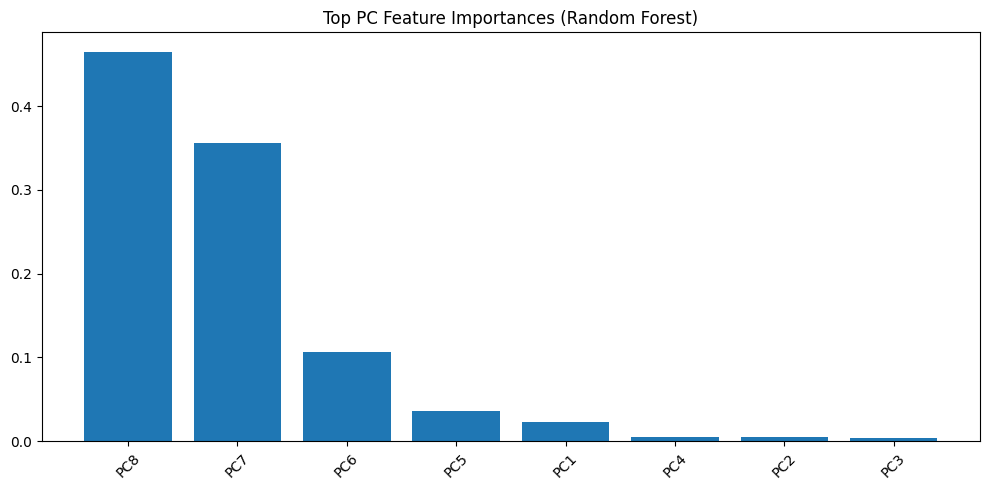

In [65]:
# Prepare labels (ensure alignment with pc_data)
labels = clean_data['Province'].values
le = LabelEncoder()
y = le.fit_transform(labels)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(normalized_data, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict & evaluate
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
print("\nConfusion Matrix:\n", cm_df)

# Feature importances (PCs)
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]
top_k = min(20, len(importances))
print("\nTop principal components by importance:")
for i in range(top_k):
    print(f"PC{idx[i]+1}: {importances[idx[i]]:.4f}")

# Plot importances
plt.figure(figsize=(10, 5))
plt.bar([f"PC{j+1}" for j in idx[:top_k]], importances[idx[:top_k]])
plt.xticks(rotation=45)
plt.title("Top PC Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

# Support Vector Machine

TRAINING SUPPORT VECTOR MACHINE (SVM)
[LibSVM]
SVM CLASSIFICATION REPORT
Accuracy: 0.9733
Weighted F1-Score: 0.9731
Weighted Precision: 0.9730
Weighted Recall: 0.9733

Detailed Classification Report:
               precision    recall  f1-score   support

 Eastern Cape     0.9813    0.9868    0.9840      1062
   Free State     0.8904    0.8850    0.8877       835
      Gauteng     0.9850    0.9996    0.9923      5706
          KZN     0.9868    0.9877    0.9872      2114
      Limpopo     0.9517    0.9114    0.9311       519
   Mpumalanga     0.9455    0.9144    0.9297      1005
   North West     0.9230    0.9025    0.9126      1036
Northern Cape     0.9846    0.9496    0.9668       337
 Western Cape     0.9990    1.0000    0.9995      1923

     accuracy                         0.9733     14537
    macro avg     0.9608    0.9486    0.9545     14537
 weighted avg     0.9730    0.9733    0.9731     14537


Confusion Matrix:
               Eastern Cape  Free State  Gauteng   KZN  Limpopo

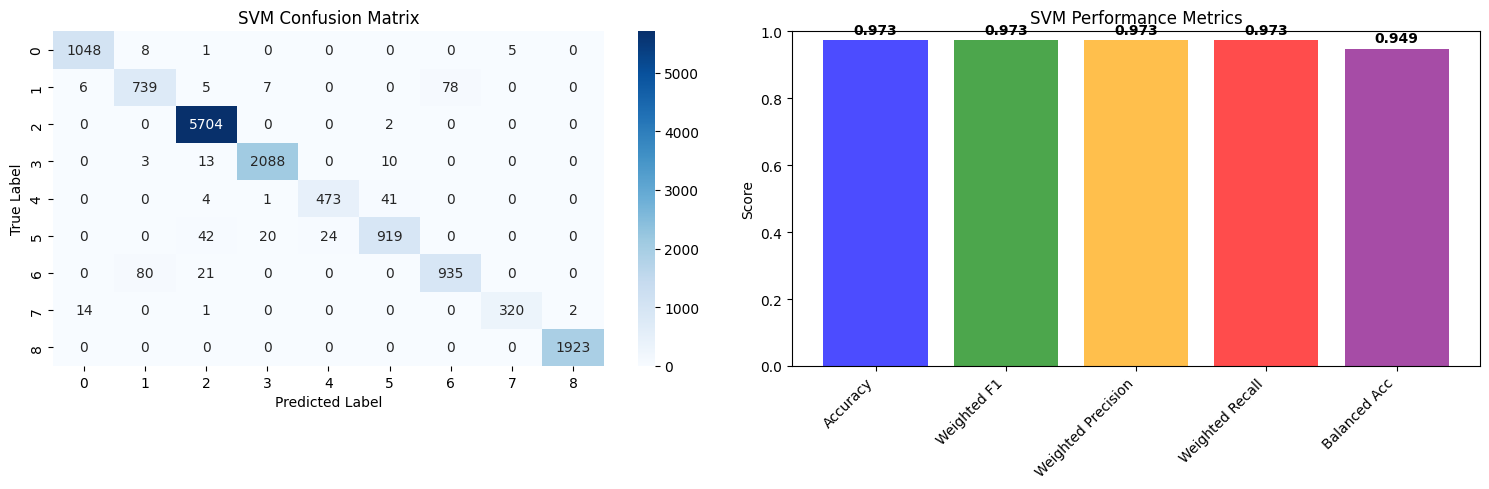


Visualization saved as 'svm_evaluation_metrics.png'


In [67]:
# Prepare data - SVM works best with scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM with RBF kernel
print("=" * 50)
print("TRAINING SUPPORT VECTOR MACHINE (SVM)")
print("=" * 50)

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42, verbose=1)
svm_model.fit(X_train_scaled, y_train_ce.numpy())

# Predict and evaluate
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)

# Calculate metrics
svm_accuracy = accuracy_score(y_test_ce.numpy(), y_pred_svm)
svm_f1 = f1_score(y_test_ce.numpy(), y_pred_svm, average='weighted')
svm_precision = precision_score(y_test_ce.numpy(), y_pred_svm, average='weighted', zero_division=0)
svm_recall = recall_score(y_test_ce.numpy(), y_pred_svm, average='weighted', zero_division=0)

print("\n" + "=" * 50)
print("SVM CLASSIFICATION REPORT")
print("=" * 50)
print(f"Accuracy: {svm_accuracy:.4f}")
print(f"Weighted F1-Score: {svm_f1:.4f}")
print(f"Weighted Precision: {svm_precision:.4f}")
print(f"Weighted Recall: {svm_recall:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test_ce.numpy(), y_pred_svm, target_names=class_names, digits=4))

# Confusion matrix
cm_svm = confusion_matrix(y_test_ce.numpy(), y_pred_svm)
cm_svm_df = pd.DataFrame(cm_svm, index=class_names, columns=class_names)
print("\nConfusion Matrix:")
print(cm_svm_df)

# ROC-AUC
try:
    svm_roc_auc_ovr = roc_auc_score(y_test_ce.numpy(), y_pred_proba_svm, multi_class='ovr', average='weighted')
    print(f"\nROC-AUC Score (One-vs-Rest, weighted): {svm_roc_auc_ovr:.4f}")
except:
    print("\nNote: ROC-AUC calculation could not be computed")

# Additional metrics

svm_kappa = cohen_kappa_score(y_test_ce.numpy(), y_pred_svm)
svm_mcc = matthews_corrcoef(y_test_ce.numpy(), y_pred_svm)
svm_bal_acc = balanced_accuracy_score(y_test_ce.numpy(), y_pred_svm)

print(f"\nCohen's Kappa: {svm_kappa:.4f}")
print(f"Matthews Correlation Coefficient: {svm_mcc:.4f}")
print(f"Balanced Accuracy: {svm_bal_acc:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix Heatmap
ax1 = axes[0]
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(num_classes), 
            yticklabels=range(num_classes),
            ax=ax1)
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')
ax1.set_title('SVM Confusion Matrix')

# Metrics Comparison
ax2 = axes[1]
svm_metrics = {
    'Accuracy': svm_accuracy,
    'Weighted F1': svm_f1,
    'Weighted Precision': svm_precision,
    'Weighted Recall': svm_recall,
    'Balanced Acc': svm_bal_acc
}
colors = ['blue', 'green', 'orange', 'red', 'purple']
ax2.bar(range(len(svm_metrics)), list(svm_metrics.values()), color=colors, alpha=0.7)
ax2.set_xticks(range(len(svm_metrics)))
ax2.set_xticklabels(list(svm_metrics.keys()), rotation=45, ha='right')
ax2.set_ylabel('Score')
ax2.set_title('SVM Performance Metrics')
ax2.set_ylim([0, 1])
for i, v in enumerate(svm_metrics.values()):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('svm_evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'svm_evaluation_metrics.png'")

# XGBoost

XGBoost Accuracy: 0.9825273440187109

Classification Report:
                precision    recall  f1-score   support

 Eastern Cape       0.99      0.98      0.98      1062
   Free State       0.93      0.94      0.93       835
      Gauteng       0.99      1.00      1.00      5706
          KZN       0.99      0.99      0.99      2114
      Limpopo       0.95      0.95      0.95       519
   Mpumalanga       0.96      0.94      0.95      1005
   North West       0.95      0.94      0.95      1036
Northern Cape       0.97      0.96      0.97       337
 Western Cape       1.00      1.00      1.00      1923

     accuracy                           0.98     14537
    macro avg       0.97      0.97      0.97     14537
 weighted avg       0.98      0.98      0.98     14537


Confusion Matrix:
                Eastern Cape  Free State  Gauteng   KZN  Limpopo  Mpumalanga  \
Eastern Cape           1043          10        0     0        0           0   
Free State                2         783   

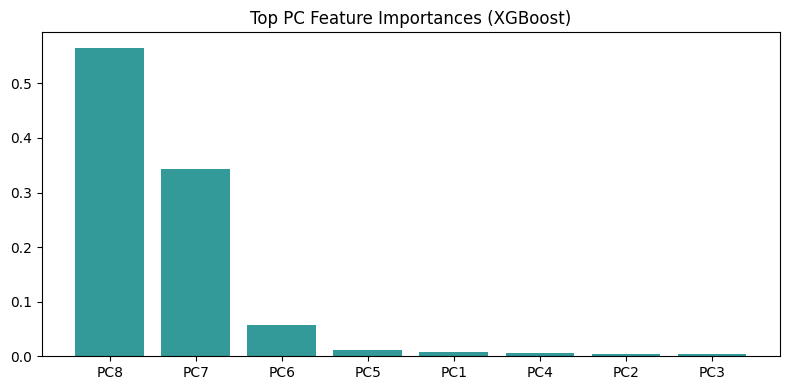


ROC-AUC OVR (weighted): 0.9997
ROC-AUC OVO (weighted): 0.9996


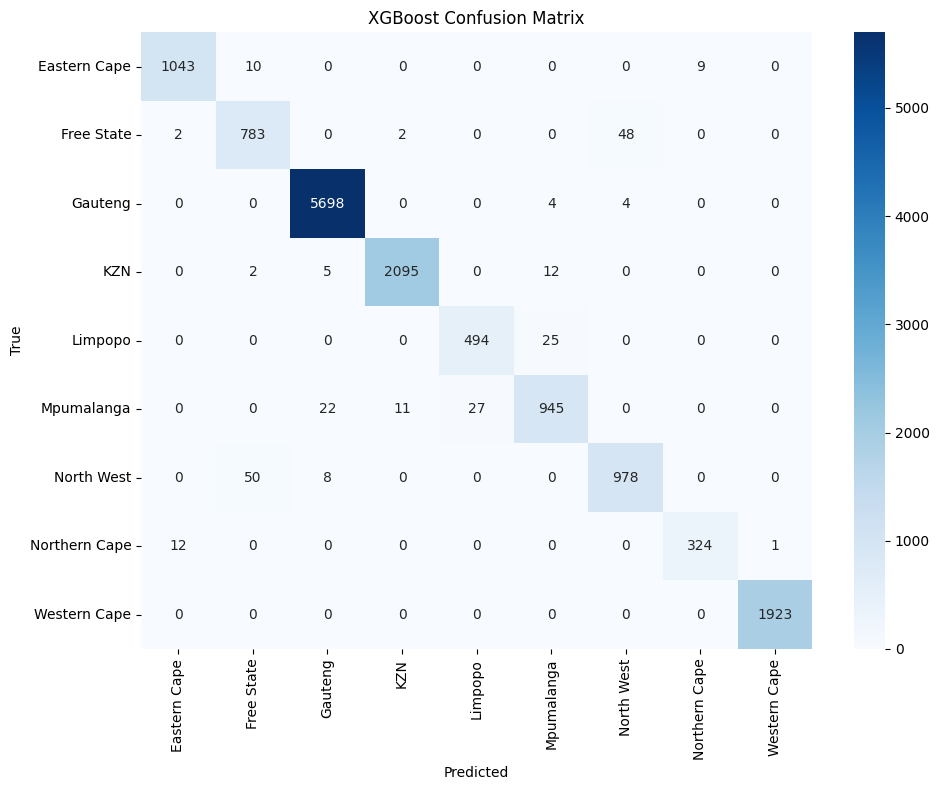

In [68]:
# 1. Train XGBoost classifier
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1
)

xgb_clf.fit(X_train, y_train)

# 2. Predict & evaluate
y_pred_xgb = xgb_clf.predict(X_test)
y_pred_proba_xgb = xgb_clf.predict_proba(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb, target_names=le.classes_))

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_xgb_df = pd.DataFrame(cm_xgb, index=le.classes_, columns=le.classes_)
print("\nConfusion Matrix:\n", cm_xgb_df)

# 3. Feature importances (principal components)
importances_xgb = xgb_clf.feature_importances_
idx_xgb = np.argsort(importances_xgb)[::-1]
top_k_xgb = min(top_k, len(importances_xgb))
print("\nTop principal components by XGBoost importance:")
for i in range(top_k_xgb):
    print(f"PC{idx_xgb[i]+1}: {importances_xgb[idx_xgb[i]]:.4f}")

# Plot top importances
plt.figure(figsize=(8, 4))
plt.bar([f"PC{j+1}" for j in idx_xgb[:top_k_xgb]], importances_xgb[idx_xgb[:top_k_xgb]], color='teal', alpha=0.8)
plt.title("Top PC Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

# 4. ROC-AUC
if num_classes == 2:
    roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb[:, 1])
    print(f"\nROC-AUC (Binary): {roc_auc_xgb:.4f}")
else:
    try:
        roc_auc_ovr_xgb = roc_auc_score(y_test, y_pred_proba_xgb, multi_class='ovr', average='weighted')
        roc_auc_ovo_xgb = roc_auc_score(y_test, y_pred_proba_xgb, multi_class='ovo', average='weighted')
        print(f"\nROC-AUC OVR (weighted): {roc_auc_ovr_xgb:.4f}")
        print(f"ROC-AUC OVO (weighted): {roc_auc_ovo_xgb:.4f}")
    except Exception as e:
        print("\nROC-AUC could not be computed:", e)

# 5. Visualization: confusion heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.savefig('xgb_evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()